# Período 2: WTI y Brent

Datos diarios crudos de EIA desde el **1 de abril de 2026** hasta la fecha actual.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "secret_api_key.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

KEY_PATH = PROJECT_ROOT / "secret_api_key.txt"
if not KEY_PATH.exists():
    raise FileNotFoundError("No se encontró secret_api_key.txt en la raíz del proyecto.")

API_KEY = KEY_PATH.read_text(encoding="utf-8").strip()
if not API_KEY:
    raise ValueError("secret_api_key.txt está vacío.")

print("API key cargada sin mostrarla.")

API key cargada sin mostrarla.


In [2]:
API_URL = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
FECHA_ACTUAL = pd.Timestamp.today().strftime("%Y-%m-%d")

parametros_periodo_2 = {
    "api_key": API_KEY,
    "frequency": "daily",
    "data[0]": "value",
    "facets[product][]": ["EPCWTI", "EPCBRENT"],
    "start": "2026-04-01",
    "end": FECHA_ACTUAL,
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000,
}

try:
    respuesta = requests.get(API_URL, params=parametros_periodo_2, timeout=60)
    respuesta.raise_for_status()
except requests.RequestException as error:
    estado = getattr(error.response, "status_code", "sin respuesta")
    raise RuntimeError(
        f"No se pudo consultar EIA (estado HTTP: {estado})."
    ) from None

contenido = respuesta.json()["response"]
df_periodo_2 = pd.DataFrame(contenido["data"])

print(f"Registros descargados: {len(df_periodo_2):,}")
display(df_periodo_2.head())
display(df_periodo_2.tail())

Registros descargados: 240


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,2026-04-01,ZEU,NA,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,Europe Brent Spot Price FOB (Dollars per Barrel),119.56,$/BBL
1,2026-04-01,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",101.9,$/BBL
2,2026-04-02,ZEU,NA,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,Europe Brent Spot Price FOB (Dollars per Barrel),127.61,$/BBL
3,2026-04-02,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",113.23,$/BBL
4,2026-04-06,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",114.01,$/BBL


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
235,2026-09-18,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",101.44,$/BBL
236,2026-09-21,ZEU,NA,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,Europe Brent Spot Price FOB (Dollars per Barrel),116.15,$/BBL
237,2026-09-21,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",96.97,$/BBL
238,2026-09-22,ZEU,NA,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,Europe Brent Spot Price FOB (Dollars per Barrel),114.89,$/BBL
239,2026-09-22,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",96.41,$/BBL


## Limpieza y validación del período 2

Se conserva `df_periodo_2` sin modificar y se crea `df_periodo_2_limpio` para trabajar con tipos correctos y valores de texto normalizados.

In [3]:
def resumen_faltantes(df):
    filas = []

    for columna in df.columns:
        serie = df[columna]
        es_texto = (
            pd.api.types.is_object_dtype(serie.dtype)
            or pd.api.types.is_string_dtype(serie.dtype)
        )

        if es_texto:
            texto = serie.astype("string")
            cadenas_vacias = int(texto.eq("").sum())
            solo_espacios = int(texto.str.fullmatch(r"\s+", na=False).sum())
        else:
            cadenas_vacias = 0
            solo_espacios = 0

        filas.append(
            {
                "columna": columna,
                "nulos": int(serie.isna().sum()),
                "cadenas_vacias": cadenas_vacias,
                "solo_espacios": solo_espacios,
            }
        )

    return pd.DataFrame(filas).set_index("columna")


tipos_antes_periodo_2 = df_periodo_2.dtypes.astype(str).rename("tipo_original")
faltantes_antes_periodo_2 = resumen_faltantes(df_periodo_2)

print("Tipos y valores faltantes antes de la limpieza:")
display(pd.concat([tipos_antes_periodo_2, faltantes_antes_periodo_2], axis=1))

Tipos y valores faltantes antes de la limpieza:


,tipo_original,nulos,cadenas_vacias,solo_espacios
period,object,0,0,0
duoarea,object,0,0,0
area-name,object,0,0,0
product,object,0,0,0
product-name,object,0,0,0
process,object,0,0,0
process-name,object,0,0,0
series,object,0,0,0
series-description,object,0,0,0
value,object,0,0,0


In [4]:
df_periodo_2_limpio = df_periodo_2.copy()

columnas_texto = [
    columna
    for columna in df_periodo_2_limpio.columns
    if columna not in {"period", "value"}
]

for columna in columnas_texto:
    df_periodo_2_limpio[columna] = (
        df_periodo_2_limpio[columna]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

df_periodo_2_limpio["period"] = pd.to_datetime(
    df_periodo_2_limpio["period"], errors="coerce"
)
df_periodo_2_limpio["value"] = pd.to_numeric(
    df_periodo_2_limpio["value"], errors="coerce"
)

duplicados_completos_antes = int(df_periodo_2_limpio.duplicated().sum())
df_periodo_2_limpio = (
    df_periodo_2_limpio.drop_duplicates().reset_index(drop=True)
)

print(f"Duplicados completos eliminados: {duplicados_completos_antes}")
print("Tipos de datos después de la conversión:")
display(df_periodo_2_limpio.dtypes.astype(str).rename("tipo_limpio").to_frame())

Duplicados completos eliminados: 0
Tipos de datos después de la conversión:


,tipo_limpio
period,datetime64[ns]
duoarea,string
area-name,string
product,string
product-name,string
process,string
process-name,string
series,string
series-description,string
value,float64


In [5]:
faltantes_despues_periodo_2 = resumen_faltantes(df_periodo_2_limpio)
duplicados_completos_despues = int(df_periodo_2_limpio.duplicated().sum())
duplicados_fecha_serie = int(
    df_periodo_2_limpio.duplicated(subset=["period", "series"]).sum()
)

resumen_validacion_periodo_2 = pd.DataFrame(
    {
        "control": [
            "Nulos",
            "Cadenas vacías",
            "Valores con solo espacios",
            "Duplicados completos",
            "Duplicados por fecha y serie",
        ],
        "cantidad": [
            int(faltantes_despues_periodo_2["nulos"].sum()),
            int(faltantes_despues_periodo_2["cadenas_vacias"].sum()),
            int(faltantes_despues_periodo_2["solo_espacios"].sum()),
            duplicados_completos_despues,
            duplicados_fecha_serie,
        ],
    }
)
resumen_validacion_periodo_2["estado"] = (
    resumen_validacion_periodo_2["cantidad"]
    .eq(0)
    .map({True: "OK", False: "REVISAR"})
)

print("Valores faltantes después de la limpieza:")
display(faltantes_despues_periodo_2)
print("Resumen final de validación:")
display(resumen_validacion_periodo_2)
display(df_periodo_2_limpio.head())

Valores faltantes después de la limpieza:


,nulos,cadenas_vacias,solo_espacios
columna,,,
period,0,0,0
duoarea,0,0,0
area-name,0,0,0
product,0,0,0
product-name,0,0,0
process,0,0,0
process-name,0,0,0
series,0,0,0
series-description,0,0,0


Resumen final de validación:


,control,cantidad,estado
0,Nulos,0,OK
1,Cadenas vacías,0,OK
2,Valores con solo espacios,0,OK
3,Duplicados completos,0,OK
4,Duplicados por fecha y serie,0,OK


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,2026-04-01,ZEU,NA,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,Europe Brent Spot Price FOB (Dollars per Barrel),119.56,$/BBL
1,2026-04-01,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",101.90,$/BBL
2,2026-04-02,ZEU,NA,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,Europe Brent Spot Price FOB (Dollars per Barrel),127.61,$/BBL
3,2026-04-02,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",113.23,$/BBL
4,2026-04-06,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",114.01,$/BBL


## Análisis exploratorio del período 2

Se revisa la cobertura temporal y se analizan los precios, los retornos entre cotizaciones consecutivas y la relación entre WTI y Brent. Cada gráfico incluye una explicación y hallazgos calculados con los datos de este período.

In [6]:
# Preparación del EDA: se conserva el dataframe limpio.
crudos = ["WTI", "Brent"]
colores = {"WTI": "#2B6CB0", "Brent": "#D97706"}
inicio_solicitado = pd.Timestamp(parametros_periodo_2["start"])
fin_solicitado = pd.Timestamp(parametros_periodo_2["end"])
fecha_consulta = pd.Timestamp.now()

# Si hay problemas estructurales, resolverlos antes de calcular indicadores.
if df_periodo_2_limpio[["period", "series", "value"]].isna().any().any():
    raise ValueError("Hay fechas, series o precios nulos: revisar la validación.")
if df_periodo_2_limpio.duplicated(["period", "series"]).any():
    raise ValueError("Hay más de un precio por fecha y serie: revisar duplicados.")
if not np.isfinite(df_periodo_2_limpio["value"]).all():
    raise ValueError("Hay precios no finitos: revisar los datos.")
if not df_periodo_2_limpio["period"].between(inicio_solicitado, fin_solicitado).all():
    raise ValueError("Se recibieron fechas fuera del período solicitado.")

precios_periodo_2 = (
    df_periodo_2_limpio.pivot(index="period", columns="series", values="value")
    .rename(columns={"RWTC": "WTI", "RBRTE": "Brent"})
    .sort_index()
)
precios_periodo_2.columns.name = None
if not set(crudos).issubset(precios_periodo_2.columns):
    raise ValueError("Falta alguna de las series WTI o Brent.")
series_precio_periodo_2 = {
    crudo: precios_periodo_2[crudo].dropna() for crudo in crudos
}
if any(len(serie) < 22 for serie in series_precio_periodo_2.values()):
    raise ValueError("Se necesitan al menos 22 cotizaciones por crudo para este EDA.")
if any(serie.eq(0).any() for serie in series_precio_periodo_2.values()):
    raise ValueError("Hay un precio cero: revisar antes de calcular retornos porcentuales.")

precios_periodo_2["Spread Brent-WTI"] = (
    precios_periodo_2["Brent"] - precios_periodo_2["WTI"]
)
precios_comunes_periodo_2 = precios_periodo_2[crudos].dropna()
if len(precios_comunes_periodo_2) < 2:
    raise ValueError("No hay suficientes fechas comunes para comparar ambos crudos.")

# Cada retorno conserva las fechas y los precios que lo originaron.
# No se rellenan precios ausentes ni se añade una cotización del otro período.
detalle = []
for crudo, serie in series_precio_periodo_2.items():
    fechas = serie.index.to_series()
    tabla = pd.DataFrame({
        "crudo": crudo,
        "fecha_inicio": fechas.shift(1),
        "fecha_fin": fechas,
        "precio_inicio": serie.shift(1),
        "precio_fin": serie,
        "retorno_pct": serie.pct_change(fill_method=None).mul(100),
        "dias_calendario": fechas.diff().dt.days,
    }).iloc[1:].copy()
    tabla["dias_calendario"] = tabla["dias_calendario"].astype(int)
    detalle.append(tabla.reset_index(drop=True))
detalle_retornos_periodo_2 = pd.concat(detalle, ignore_index=True)
retornos_periodo_2 = detalle_retornos_periodo_2.pivot(
    index="fecha_fin", columns="crudo", values="retorno_pct"
).reindex(columns=crudos).sort_index()
retornos_periodo_2.columns.name = None

# Se exige una ventana completa de 20 datos válidos de la propia serie.
media_movil_20_periodo_2 = pd.DataFrame({
    crudo: serie.rolling(20, min_periods=20).mean()
    for crudo, serie in series_precio_periodo_2.items()
})
volatilidad_20_periodo_2 = pd.DataFrame({
    crudo: retornos_periodo_2[crudo].dropna().rolling(20, min_periods=20).std(ddof=1)
    for crudo in crudos
})
promedio_mensual_periodo_2 = precios_periodo_2[crudos].resample("MS").mean()

# Para correlacionar retornos deben coincidir AMBOS extremos del intervalo.
columnas_intervalo = ["fecha_inicio", "fecha_fin", "retorno_pct"]
retornos_comparables_periodo_2 = (
    detalle_retornos_periodo_2.loc[
        detalle_retornos_periodo_2["crudo"].eq("WTI"), columnas_intervalo
    ].merge(
        detalle_retornos_periodo_2.loc[
            detalle_retornos_periodo_2["crudo"].eq("Brent"), columnas_intervalo
        ],
        on=["fecha_inicio", "fecha_fin"], how="inner",
        suffixes=("_WTI", "_Brent"), validate="one_to_one",
    ).sort_values("fecha_fin").reset_index(drop=True)
)
corr_retornos_periodo_2 = retornos_comparables_periodo_2[
    ["retorno_pct_WTI", "retorno_pct_Brent"]
].corr().iloc[0, 1]

def resumir_precio(serie):
    serie = serie.dropna()
    frecuencias = serie.value_counts()
    frecuencia_maxima = int(frecuencias.iloc[0])
    valores_modales = frecuencias[frecuencias.eq(frecuencia_maxima)].index.sort_values()
    if frecuencia_maxima == 1:
        moda = "Sin moda repetida"
    else:
        moda = ", ".join(f"{valor:.2f}" for valor in valores_modales)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    return pd.Series(
        {
            "observaciones": len(serie),
            "precio inicial": serie.iloc[0],
            "precio final": serie.iloc[-1],
            "variación total (%)": (serie.iloc[-1] / serie.iloc[0] - 1) * 100,
            "promedio": serie.mean(),
            "mediana": serie.median(),
            "moda(s)": moda,
            "frecuencia máxima": frecuencia_maxima,
            "varianza": serie.var(),
            "desvío estándar": serie.std(),
            "rango": serie.max() - serie.min(),
            "rango intercuartílico": q3 - q1,
            "coeficiente de variación (%)": serie.std() / serie.mean() * 100,
            "mínimo": serie.min(),
            "fecha mínimo": serie.idxmin().date().isoformat(),
            "máximo": serie.max(),
            "fecha máximo": serie.idxmax().date().isoformat(),
        }
    )

resumen_precios_periodo_2 = pd.DataFrame(
    {
        "WTI": resumir_precio(precios_periodo_2["WTI"]),
        "Brent": resumir_precio(precios_periodo_2["Brent"]),
    }
).T
columnas_numericas_resumen = [
    "precio inicial", "precio final", "variación total (%)", "promedio",
    "mediana", "varianza", "desvío estándar", "rango",
    "rango intercuartílico", "coeficiente de variación (%)", "mínimo", "máximo",
]
resumen_precios_periodo_2[columnas_numericas_resumen] = (
    resumen_precios_periodo_2[columnas_numericas_resumen].astype(float).round(2)
)
resumen_precios_periodo_2[["observaciones", "frecuencia máxima"]] = (
    resumen_precios_periodo_2[["observaciones", "frecuencia máxima"]].astype(int)
)

In [7]:
display(Markdown("### Cobertura temporal"))

# Cobertura: filas completas no implican que todas las fechas estén presentes.
cobertura_periodo_2 = pd.DataFrame([
    {
        "crudo": crudo,
        "primera cotización": serie.index.min().date().isoformat(),
        "última cotización": serie.index.max().date().isoformat(),
        "cotizaciones": len(serie),
        "retornos disponibles": int(retornos_periodo_2[crudo].count()),
        "fechas comunes con el otro crudo": len(precios_comunes_periodo_2),
    }
    for crudo, serie in series_precio_periodo_2.items()
]).set_index("crudo")

solo_un_crudo_periodo_2 = precios_periodo_2[crudos].loc[
    precios_periodo_2[crudos].isna().any(axis=1)
].copy()
solo_un_crudo_periodo_2["sin cotización"] = solo_un_crudo_periodo_2[crudos].apply(
    lambda fila: ", ".join(fila.index[fila.isna()]), axis=1
)

# Lunes a viernes es una referencia; no es un calendario oficial de mercado.
fechas_laborables = pd.date_range(inicio_solicitado, fin_solicitado, freq="B")
sin_ambos = fechas_laborables.difference(precios_periodo_2.index)
sin_ambos_periodo_2 = pd.DataFrame({"fecha": sin_ambos})
sin_ambos_periodo_2["situación"] = [
    "Posterior a la última publicación recibida"
    if fecha > precios_periodo_2.index.max()
    else "Sin precio de ambos (feriado o ausencia por verificar)"
    for fecha in sin_ambos
]
duracion_retornos_periodo_2 = pd.crosstab(
    detalle_retornos_periodo_2["dias_calendario"],
    detalle_retornos_periodo_2["crudo"],
).reindex(columns=crudos, fill_value=0)

filas_mensuales = []
for mes in pd.period_range(inicio_solicitado, fin_solicitado, freq="M"):
    inicio_mes, fin_mes = mes.start_time, mes.end_time.normalize()
    ultimo_lunes_viernes = pd.date_range(inicio_mes, fin_mes, freq="B")[-1]
    for crudo, serie in series_precio_periodo_2.items():
        datos_mes = serie.loc[serie.index.to_period("M") == mes]
        if datos_mes.empty:
            estado = "Sin cotizaciones recibidas"
        elif inicio_solicitado > inicio_mes or fin_solicitado < fin_mes:
            estado = "Parcial: límite de la consulta"
        elif fin_mes >= fecha_consulta.normalize():
            estado = "Parcial: mes en curso"
        elif datos_mes.index.max() < ultimo_lunes_viernes:
            estado = "Cierre por verificar (publicación/feriado)"
        else:
            estado = "Mes cerrado; revisar ausencias internas"
        filas_mensuales.append({
            "mes": mes.start_time, "crudo": crudo,
            "cotizaciones": len(datos_mes),
            "primera fecha": datos_mes.index.min() if len(datos_mes) else pd.NaT,
            "última fecha": datos_mes.index.max() if len(datos_mes) else pd.NaT,
            "promedio": datos_mes.mean(),
            "estado": estado,
        })
cobertura_mensual_periodo_2 = pd.DataFrame(filas_mensuales)

display(Markdown(
    f"**Consulta:** {fecha_consulta:%Y-%m-%d %H:%M}. "
    f"**Rango solicitado:** {inicio_solicitado:%Y-%m-%d} a {fin_solicitado:%Y-%m-%d}."
))
display(cobertura_periodo_2)
display(Markdown("**Fechas con cotización de un solo crudo:**"))
display(solo_un_crudo_periodo_2)
display(Markdown("**Fechas de lunes a viernes sin cotización de ninguno:**"))
display(sin_ambos_periodo_2)
display(Markdown("**Días calendario que abarca cada retorno:**"))
display(duracion_retornos_periodo_2)
display(Markdown("**Cobertura mensual:**"))
display(cobertura_mensual_periodo_2.round({"promedio": 2}))
display(Markdown(
    "Los controles de nulos se refieren a las filas recibidas. Las tablas anteriores "
    "muestran las fechas ausentes al comparar calendarios. No se imputan precios. "
    "Los días sin datos pueden corresponder a feriados o al retraso de publicación; "
    "no se etiquetan automáticamente como errores. Un retorno entre viernes y lunes "
    "abarca tres días calendario y sigue siendo una variación entre cotizaciones consecutivas. "
    "Las ventanas móviles requieren 20 cotizaciones o retornos válidos y no equivalen "
    "a 20 días calendario. El primer retorno del período no utiliza precios del período anterior."
))

### Cobertura temporal

**Consulta:** 2026-09-28 12:58. **Rango solicitado:** 2026-04-01 a 2026-09-28.

,primera cotización,última cotización,cotizaciones,retornos disponibles,fechas comunes con el otro crudo
crudo,,,,,
WTI,2026-04-01,2026-09-22,120,119,117
Brent,2026-04-01,2026-09-22,120,119,117


**Fechas con cotización de un solo crudo:**

,WTI,Brent,sin cotización
period,,,
2026-04-06,114.01,NaN,Brent
2026-05-04,109.76,NaN,Brent
2026-06-19,NaN,80.46,WTI
2026-07-03,NaN,68.68,WTI
2026-08-31,87.03,NaN,Brent
2026-09-07,NaN,104.47,WTI


...

**Días calendario que abarca cada retorno:**

crudo,WTI,Brent
dias_calendario,,
1,94,94
3,20,21
4,5,3
5,0,1


**Cobertura mensual:**

,mes,crudo,cotizaciones,primera fecha,última fecha,promedio,estado
0,2026-04-01,WTI,21,2026-04-01,2026-04-30,100.32,Mes cerrado; revisar ausencias internas
1,2026-04-01,Brent,20,2026-04-01,2026-04-30,117.29,Mes cerrado; revisar ausencias internas
2,2026-05-01,WTI,20,2026-05-01,2026-05-29,102.13,Mes cerrado; revisar ausencias internas
3,2026-05-01,Brent,19,2026-05-01,2026-05-29,107.14,Mes cerrado; revisar ausencias internas
4,2026-06-01,WTI,21,2026-06-01,2026-06-30,84.81,Mes cerrado; revisar ausencias internas
5,2026-06-01,Brent,22,2026-06-01,2026-06-30,85.40,Mes cerrado; revisar ausencias internas
6,2026-07-01,WTI,22,2026-07-01,2026-07-31,80.46,Mes cerrado; revisar ausencias internas
7,2026-07-01,Brent,23,2026-07-01,2026-07-31,83.76,Mes cerrado; revisar ausencias internas
8,2026-08-01,WTI,21,2026-08-03,2026-08-31,83.90,Mes cerrado; revisar ausencias internas
9,2026-08-01,Brent,20,2026-08-03,2026-08-28,91.08,Cierre por verificar (publicación/feriado)


Los controles de nulos se refieren a las filas recibidas. Las tablas anteriores muestran las fechas ausentes al comparar calendarios. No se imputan precios. Los días sin datos pueden corresponder a feriados o al retraso de publicación; no se etiquetan automáticamente como errores. Un retorno entre viernes y lunes abarca tres días calendario y sigue siendo una variación entre cotizaciones consecutivas. Las ventanas móviles requieren 20 cotizaciones o retornos válidos y no equivalen a 20 días calendario. El primer retorno del período no utiliza precios del período anterior.

### Medidas descriptivas y relación entre crudos

In [8]:
print("Medidas descriptivas de precios:")
display(resumen_precios_periodo_2)
display(Markdown(
    "Media, mediana, moda, rango, rango intercuartílico y desvío estándar se expresan "
    "en USD por barril; la varianza, en (USD por barril)²; el coeficiente de variación, "
    "en porcentaje. Varianza y desvío son muestrales (divisor n−1). "
    "La moda depende de los precios redondeados publicados y puede aportar poco cuando "
    "sus repeticiones son escasas. La dispersión del nivel de precios y la volatilidad "
    "de los retornos describen aspectos diferentes."
))
correlaciones_periodo_2 = pd.DataFrame({
    "métrica": ["Precios en fechas comunes", "Retornos con mismo inicio y fin"],
    "correlación": [
        precios_comunes_periodo_2.corr().loc["WTI", "Brent"],
        corr_retornos_periodo_2,
    ],
    "pares utilizados": [
        len(precios_comunes_periodo_2), len(retornos_comparables_periodo_2),
    ],
})
display(correlaciones_periodo_2.round(3))
display(Markdown(
    "La correlación de precios puede reflejar tendencias compartidas. "
    "La de retornos describe cuánto coinciden las variaciones en intervalos comparables; "
    "ninguna de las dos demuestra causalidad."
))

Medidas descriptivas de precios:


,observaciones,precio inicial,precio final,variación total (%),promedio,mediana,moda(s),frecuencia máxima,varianza,desvío estándar,rango,rango intercuartílico,coeficiente de variación (%),mínimo,fecha mínimo,máximo,fecha máximo
WTI,120,101.90,96.41,-5.39,91.15,92.02,86.04,2,127.99,11.31,44.98,15.97,12.41,69.60,2026-07-06,114.58,2026-04-07
Brent,120,119.56,114.89,-3.91,98.46,97.03,Sin moda repetida,1,261.78,16.18,69.68,24.47,16.43,68.53,2026-07-02,138.21,2026-04-07


Media, mediana, moda, rango, rango intercuartílico y desvío estándar se expresan en USD por barril; la varianza, en (USD por barril)²; el coeficiente de variación, en porcentaje. Varianza y desvío son muestrales (divisor n−1). La moda depende de los precios redondeados publicados y puede aportar poco cuando sus repeticiones son escasas. La dispersión del nivel de precios y la volatilidad de los retornos describen aspectos diferentes.

,métrica,correlación,pares utilizados
0,Precios en fechas comunes,0.932,117
1,Retornos con mismo inicio y fin,0.854,110


La correlación de precios puede reflejar tendencias compartidas. La de retornos describe cuánto coinciden las variaciones en intervalos comparables; ninguna de las dos demuestra causalidad.

### Intervalo de confianza del 95% para la media del precio

Para WTI y Brent se calcula por separado el intervalo t de Student con las cotizaciones disponibles de este período:

$$
IC_{95\%}(\mu) = \bar{x} \pm t_{0.975,\,n-1}\frac{s}{\sqrt{n}}
$$

Aquí, `n` es la cantidad de cotizaciones y `s` es el desvío estándar muestral. La media y ambos límites se expresan en USD por barril. La interpretación nominal del 95% supone observaciones aproximadamente independientes; la autocorrelación de los precios diarios puede hacer que estos intervalos resulten demasiado estrechos.

In [19]:
from scipy.stats import t

filas_ic_media_periodo_2 = []
for crudo in crudos:
    serie = series_precio_periodo_2[crudo]
    n = len(serie)
    media = serie.mean()
    error_estandar = serie.std(ddof=1) / np.sqrt(n)
    margen = t.ppf(0.975, df=n - 1) * error_estandar
    filas_ic_media_periodo_2.append({
        "Crudo": crudo,
        "Cotizaciones (n)": n,
        "Media (USD/barril)": media,
        "Límite inferior (USD/barril)": media - margen,
        "Límite superior (USD/barril)": media + margen,
    })

ic_media_95_periodo_2 = pd.DataFrame(filas_ic_media_periodo_2).set_index("Crudo")
display(ic_media_95_periodo_2.round(2))

,Cotizaciones (n),Media (USD/barril),Límite inferior (USD/barril),Límite superior (USD/barril)
Crudo,,,,
WTI,120,91.15,89.11,93.20
Brent,120,98.46,95.54,101.39


### Evolución del precio y media móvil

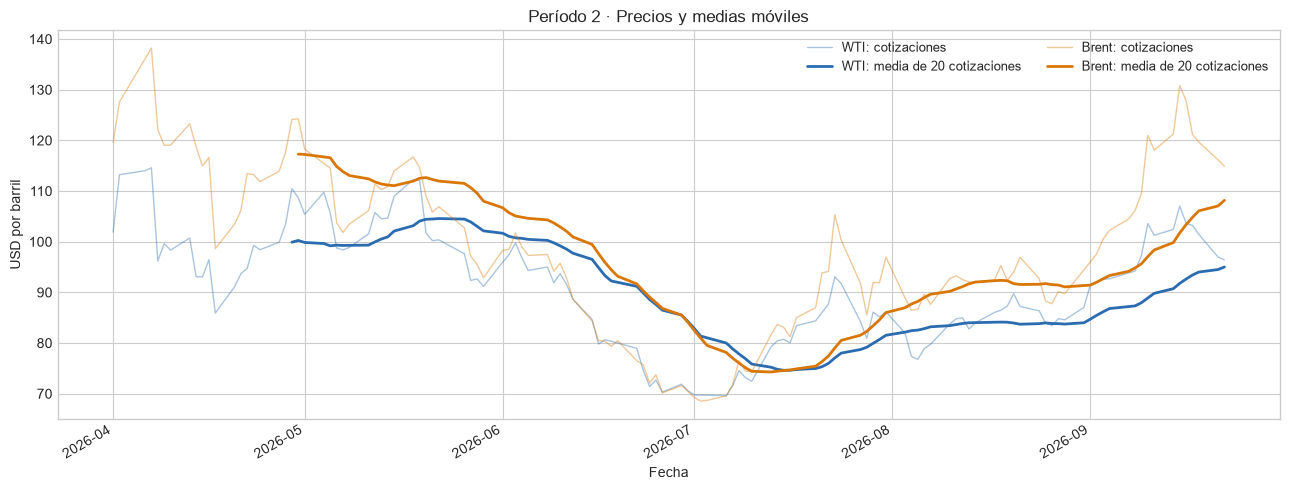

**Cómo leerlo.** Las líneas suaves reúnen exactamente 20 cotizaciones disponibles de cada crudo; aparecen después de contar con esas 20 observaciones. Las líneas finas conectan los precios publicados sin crear precios para fechas ausentes.

**Qué se observa.**

- WTI: de USD 101.90 (01/04/2026) a USD 96.41 (22/09/2026), cambio de -5.39%. Máximo: USD 114.58 el 07/04/2026; mínimo: USD 69.60 el 06/07/2026.

- Brent: de USD 119.56 (01/04/2026) a USD 114.89 (22/09/2026), cambio de -3.91%. Máximo: USD 138.21 el 07/04/2026; mínimo: USD 68.53 el 02/07/2026.

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
for crudo in crudos:
    serie = series_precio_periodo_2[crudo]
    media = media_movil_20_periodo_2[crudo].dropna()
    ax.plot(serie.index, serie, color=colores[crudo], alpha=0.4,
            linewidth=1, label=f"{crudo}: cotizaciones")
    ax.plot(media.index, media, color=colores[crudo], linewidth=2,
            label=f"{crudo}: media de 20 cotizaciones")
ax.set(title="Período 2 · Precios y medias móviles", xlabel="Fecha", ylabel="USD por barril")
ax.legend(ncol=2, fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

explicacion = [
    "**Cómo leerlo.** Las líneas suaves reúnen exactamente 20 cotizaciones disponibles "
    "de cada crudo; aparecen después de contar con esas 20 observaciones. "
    "Las líneas finas conectan los precios publicados sin crear precios para fechas ausentes.",
    "**Qué se observa.**",
]
for crudo, serie in series_precio_periodo_2.items():
    cambio = (serie.iloc[-1] / serie.iloc[0] - 1) * 100
    explicacion.append(
        f"- {crudo}: de USD {serie.iloc[0]:.2f} ({serie.index[0]:%d/%m/%Y}) "
        f"a USD {serie.iloc[-1]:.2f} ({serie.index[-1]:%d/%m/%Y}), cambio de {cambio:+.2f}%. "
        f"Máximo: USD {serie.max():.2f} el {serie.idxmax():%d/%m/%Y}; "
        f"mínimo: USD {serie.min():.2f} el {serie.idxmin():%d/%m/%Y}."
    )
display(Markdown("\n\n".join(explicacion)))

### Promedios mensuales y cobertura

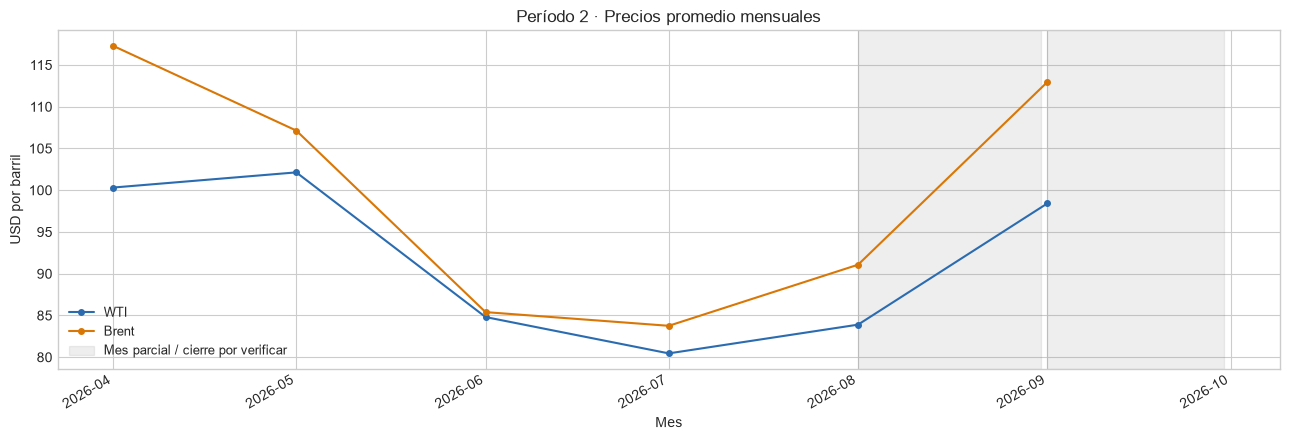

**Cómo leerlo.** Cada punto promedia únicamente las cotizaciones publicadas en ese mes. El punto se ubica al inicio del mes como etiqueta, no como precio de ese día. Las zonas grises indican cobertura parcial o un cierre que debe revisarse en la tabla mensual.

**Qué se observa.**

- WTI: mayor promedio en 2026-05 (USD 102.13) y menor en 2026-07 (USD 80.46).

- Brent: mayor promedio en 2026-04 (USD 117.29) y menor en 2026-07 (USD 83.76).

Los promedios de meses parciales son provisionales. Cada crudo puede tener distinta cantidad de cotizaciones dentro de un mes; el spread se calcula por separado en fechas coincidentes.

In [10]:
fig, ax = plt.subplots(figsize=(13, 4.5))
for crudo in crudos:
    mensual = promedio_mensual_periodo_2[crudo].dropna()
    ax.plot(mensual.index, mensual, marker="o", markersize=4,
            color=colores[crudo], label=crudo)
# Sombrear meses parciales o con un cierre cuya cobertura requiere revisión.
meses_marcados = cobertura_mensual_periodo_2.loc[
    ~cobertura_mensual_periodo_2["estado"].str.startswith("Mes cerrado"), "mes"
].drop_duplicates().sort_values()
for posicion, mes in enumerate(meses_marcados):
    ax.axvspan(mes, mes + pd.offsets.MonthEnd(0), color="gray", alpha=0.13,
               label="Mes parcial / cierre por verificar" if posicion == 0 else None)
ax.set(title="Período 2 · Precios promedio mensuales",
       xlabel="Mes", ylabel="USD por barril")
ax.legend(fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

texto = [
    "**Cómo leerlo.** Cada punto promedia únicamente las cotizaciones publicadas "
    "en ese mes. El punto se ubica al inicio del mes como etiqueta, no como precio de ese día. "
    "Las zonas grises indican cobertura parcial o un cierre que debe revisarse en la tabla mensual.",
    "**Qué se observa.**",
]
for crudo in crudos:
    serie = promedio_mensual_periodo_2[crudo].dropna()
    texto.append(
        f"- {crudo}: mayor promedio en {serie.idxmax():%Y-%m} "
        f"(USD {serie.max():.2f}) y menor en {serie.idxmin():%Y-%m} (USD {serie.min():.2f})."
    )
texto.append(
    "Los promedios de meses parciales son provisionales. Cada crudo puede tener distinta "
    "cantidad de cotizaciones dentro de un mes; el spread se calcula por separado en fechas coincidentes."
)
display(Markdown("\n\n".join(texto)))

### Diferencia entre Brent y WTI

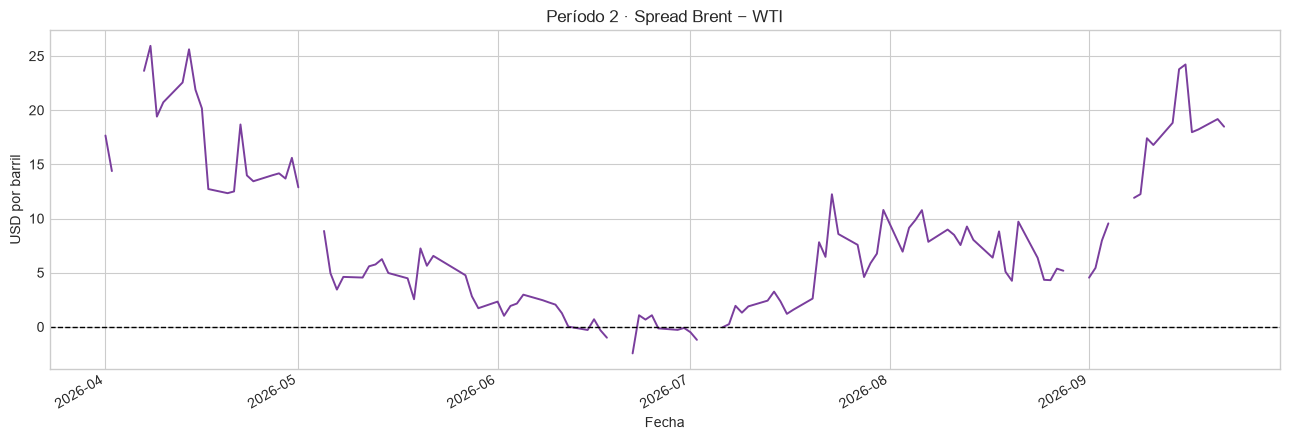

**Cómo leerlo.** Un spread positivo indica que Brent cotiza por encima de WTI; uno negativo indica lo contrario. Los cortes corresponden a fechas presentes en la tabla en las que falta uno de los dos precios. Si no hay precios de ninguno, esa fecha no forma parte de la línea.

**Qué se observa.** En 117 fechas comparables, el spread promedió USD 7.98 y fue positivo el 91.5% de las veces. Mínimo: USD -2.45 (22/06/2026); máximo: USD 25.94 (08/04/2026). Última diferencia observada: USD 18.48 (22/09/2026).

In [11]:
spread_periodo_2 = precios_periodo_2["Spread Brent-WTI"].dropna()
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(precios_periodo_2.index, precios_periodo_2["Spread Brent-WTI"],
        color="#7A3E9D", linewidth=1.4)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(title="Período 2 · Spread Brent − WTI",
       xlabel="Fecha", ylabel="USD por barril")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

display(Markdown(
    "**Cómo leerlo.** Un spread positivo indica que Brent cotiza por encima de WTI; "
    "uno negativo indica lo contrario. Los cortes corresponden a fechas presentes "
    "en la tabla en las que falta uno de los dos precios. Si no hay precios de ninguno, "
    "esa fecha no forma parte de la línea.\n\n"
    f"**Qué se observa.** En {len(spread_periodo_2)} fechas comparables, "
    f"el spread promedió USD {spread_periodo_2.mean():.2f} y fue positivo "
    f"el {spread_periodo_2.gt(0).mean() * 100:.1f}% de las veces. "
    f"Mínimo: USD {spread_periodo_2.min():.2f} ({spread_periodo_2.idxmin():%d/%m/%Y}); "
    f"máximo: USD {spread_periodo_2.max():.2f} ({spread_periodo_2.idxmax():%d/%m/%Y}). "
    f"Última diferencia observada: USD {spread_periodo_2.iloc[-1]:.2f} "
    f"({spread_periodo_2.index[-1]:%d/%m/%Y})."
))

### Evolución diaria de los retornos

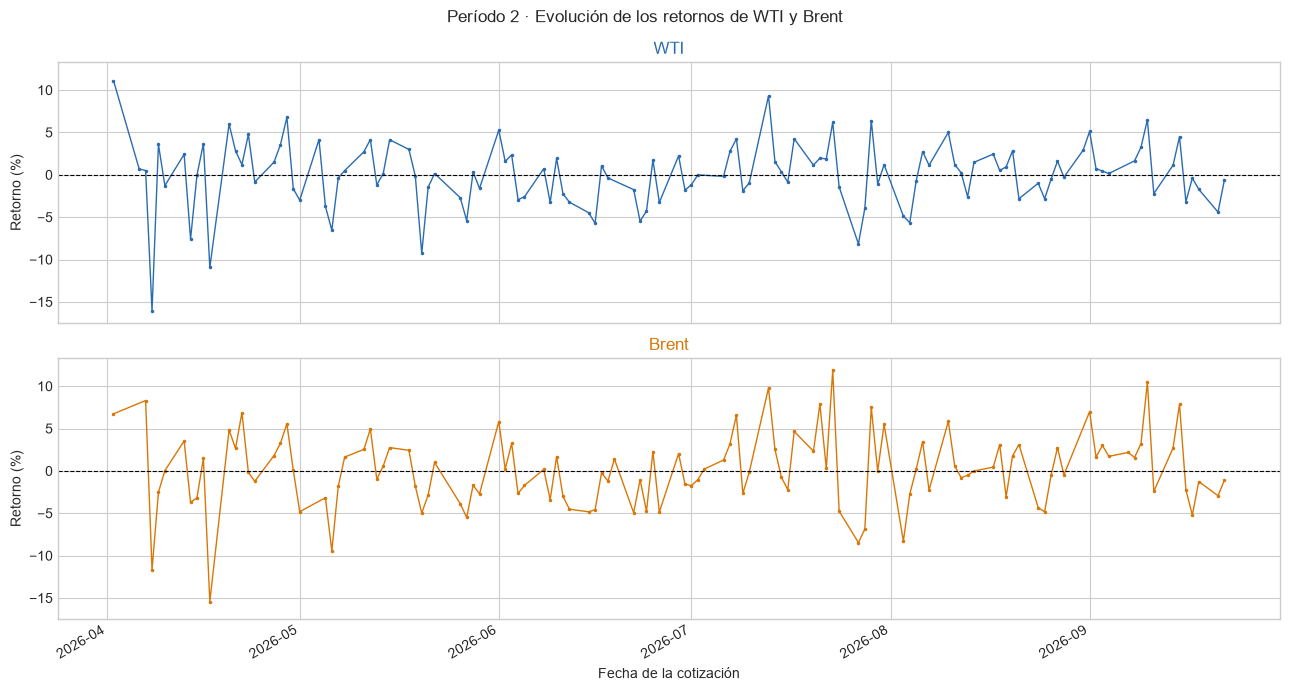

**Cómo leerlo.** Cada punto muestra el retorno porcentual del crudo en la fecha de la cotización: (precio actual / precio de la cotización anterior − 1) × 100. Un valor positivo indica una suba, uno negativo una caída y la línea punteada marca 0%. Ambos paneles usan la misma escala vertical para facilitar la comparación.

**Qué se observa.**

- WTI: 119 retornos; mayor suba de +11.12% el 02/04/2026 y mayor caída de -16.07% el 08/04/2026. Último retorno: -0.58% el 22/09/2026.

- Brent: 119 retornos; mayor suba de +11.90% el 23/07/2026 y mayor caída de -15.43% el 17/04/2026. Último retorno: -1.08% el 22/09/2026.

Cada retorno compara dos cotizaciones consecutivas disponibles del mismo crudo. Entre ellas pueden pasar varios días calendario (por ejemplo, un fin de semana); las líneas solo conectan observaciones y no representan retornos en fechas sin cotización. La primera cotización del período no tiene retorno previo dentro de él.

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, sharey=True)
for ax, crudo in zip(axes, crudos):
    serie = retornos_periodo_2[crudo].dropna()
    ax.plot(serie.index, serie, color=colores[crudo], linewidth=1,
            marker=".", markersize=3)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set(title=crudo, ylabel="Retorno (%)")
    ax.title.set_color(colores[crudo])
axes[-1].set_xlabel("Fecha de la cotización")
fig.suptitle("Período 2 · Evolución de los retornos de WTI y Brent")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

texto = [
    "**Cómo leerlo.** Cada punto muestra el retorno porcentual del crudo en la fecha "
    "de la cotización: (precio actual / precio de la cotización anterior − 1) × 100. "
    "Un valor positivo indica una suba, uno negativo una caída y la línea punteada marca 0%. "
    "Ambos paneles usan la misma escala vertical para facilitar la comparación.",
    "**Qué se observa.**",
]
for crudo in crudos:
    serie = retornos_periodo_2[crudo].dropna()
    texto.append(
        f"- {crudo}: {len(serie)} retornos; mayor suba de {serie.max():+.2f}% "
        f"el {serie.idxmax():%d/%m/%Y} y mayor caída de {serie.min():+.2f}% "
        f"el {serie.idxmin():%d/%m/%Y}. Último retorno: {serie.iloc[-1]:+.2f}% "
        f"el {serie.index[-1]:%d/%m/%Y}."
    )
texto.append(
    "Cada retorno compara dos cotizaciones consecutivas disponibles del mismo crudo. "
    "Entre ellas pueden pasar varios días calendario (por ejemplo, un fin de semana); "
    "las líneas solo conectan observaciones y no representan retornos en fechas sin cotización. "
    "La primera cotización del período no tiene retorno previo dentro de él."
)
display(Markdown("\n\n".join(texto)))

### Distribución de los retornos

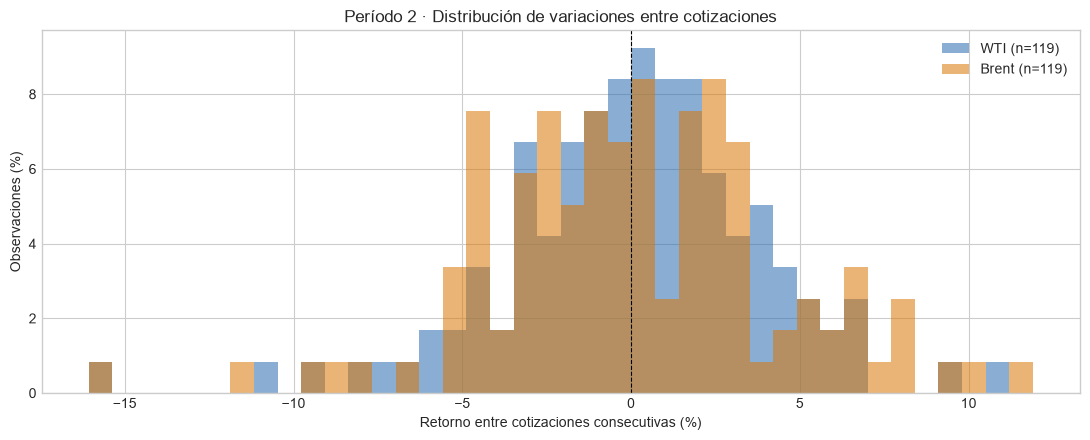

**Cómo leerlo.** Cada barra indica el porcentaje de retornos en un intervalo. Las barras de cada crudo suman 100% y comparten los mismos límites. Los valores negativos son caídas; los positivos, subas. Las colas muestran movimientos grandes.

**Qué se observa.**

- WTI: mediana +0.24%; 52.9% de retornos positivos y 47.1% negativos; rango de -16.07% a +11.12%.

- Brent: mediana -0.01%; 49.6% de retornos positivos y 50.4% negativos; rango de -15.43% a +11.90%.

Son retornos entre cotizaciones consecutivas, que pueden abarcar más de un día calendario. Se conserva la duración de cada intervalo en la tabla de retornos.

In [12]:
# Los límites de las barras son idénticos para WTI y Brent dentro del período.
limites_histograma_periodo_2 = np.histogram_bin_edges(
    detalle_retornos_periodo_2["retorno_pct"].to_numpy(), bins=40
)
fig, ax = plt.subplots(figsize=(11, 4.5))
for crudo in crudos:
    datos = retornos_periodo_2[crudo].dropna()
    ax.hist(datos, bins=limites_histograma_periodo_2,
            weights=np.full(len(datos), 100.0 / len(datos)),
            color=colores[crudo], alpha=0.55, label=f"{crudo} (n={len(datos)})")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set(title="Período 2 · Distribución de variaciones entre cotizaciones",
       xlabel="Retorno entre cotizaciones consecutivas (%)", ylabel="Observaciones (%)")
ax.legend()
plt.tight_layout()
plt.show()

texto = [
    "**Cómo leerlo.** Cada barra indica el porcentaje de retornos en un intervalo. "
    "Las barras de cada crudo suman 100% y comparten los mismos límites. "
    "Los valores negativos son caídas; los positivos, subas. Las colas muestran movimientos grandes.",
    "**Qué se observa.**",
]
for crudo in crudos:
    datos = retornos_periodo_2[crudo].dropna()
    texto.append(
        f"- {crudo}: mediana {datos.median():+.2f}%; "
        f"{datos.gt(0).mean() * 100:.1f}% de retornos positivos y "
        f"{datos.lt(0).mean() * 100:.1f}% negativos; "
        f"rango de {datos.min():+.2f}% a {datos.max():+.2f}%."
    )
texto.append(
    "Son retornos entre cotizaciones consecutivas, que pueden abarcar más de un día calendario. "
    "Se conserva la duración de cada intervalo en la tabla de retornos."
)
display(Markdown("\n\n".join(texto)))

### Volatilidad móvil

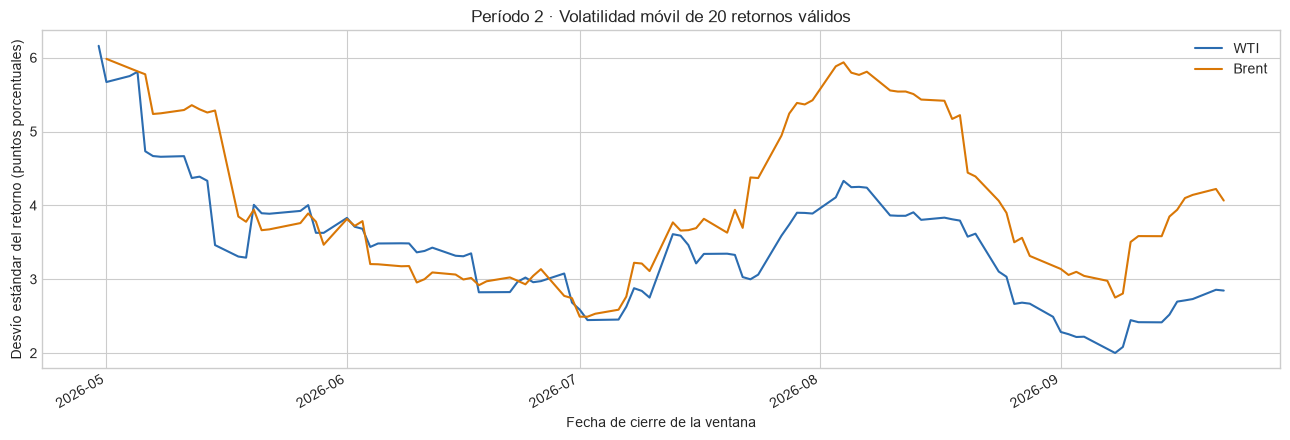

**Cómo leerlo.** Cada punto es el desvío estándar muestral de los últimos 20 retornos válidos del crudo. Una línea más alta indica movimientos más variables, tanto al alza como a la baja. La serie comienza al reunir 20 retornos; no está anualizada.

**Qué se observa.**

- WTI: desvío de todos sus retornos 3.90 puntos porcentuales. Pico móvil de 6.16 al 30/04/2026; último valor móvil: 2.85.

- Brent: desvío de todos sus retornos 4.42 puntos porcentuales. Pico móvil de 5.98 al 01/05/2026; último valor móvil: 4.07.

La fecha del pico cierra una ventana de 20 retornos: no identifica por sí sola un evento causal. Las ventanas de WTI y Brent pueden abarcar fechas diferentes por sus calendarios de publicación.

In [13]:
volatilidad_diaria_periodo_2 = retornos_periodo_2.std(ddof=1)
fig, ax = plt.subplots(figsize=(13, 4.5))
for crudo in crudos:
    serie = volatilidad_20_periodo_2[crudo].dropna()
    ax.plot(serie.index, serie, color=colores[crudo], label=crudo)
ax.set(title="Período 2 · Volatilidad móvil de 20 retornos válidos",
       xlabel="Fecha de cierre de la ventana", ylabel="Desvío estándar del retorno (puntos porcentuales)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

texto = [
    "**Cómo leerlo.** Cada punto es el desvío estándar muestral de los últimos 20 retornos "
    "válidos del crudo. Una línea más alta indica movimientos más variables, tanto al alza "
    "como a la baja. La serie comienza al reunir 20 retornos; no está anualizada.",
    "**Qué se observa.**",
]
for crudo in crudos:
    serie = volatilidad_20_periodo_2[crudo].dropna()
    texto.append(
        f"- {crudo}: desvío de todos sus retornos {volatilidad_diaria_periodo_2[crudo]:.2f} "
        f"puntos porcentuales. Pico móvil de {serie.max():.2f} al {serie.idxmax():%d/%m/%Y}; "
        f"último valor móvil: {serie.iloc[-1]:.2f}."
    )
texto.append(
    "La fecha del pico cierra una ventana de 20 retornos: no identifica por sí sola un evento causal. "
    "Las ventanas de WTI y Brent pueden abarcar fechas diferentes por sus calendarios de publicación."
)
display(Markdown("\n\n".join(texto)))

### Evolución relativa: base 100

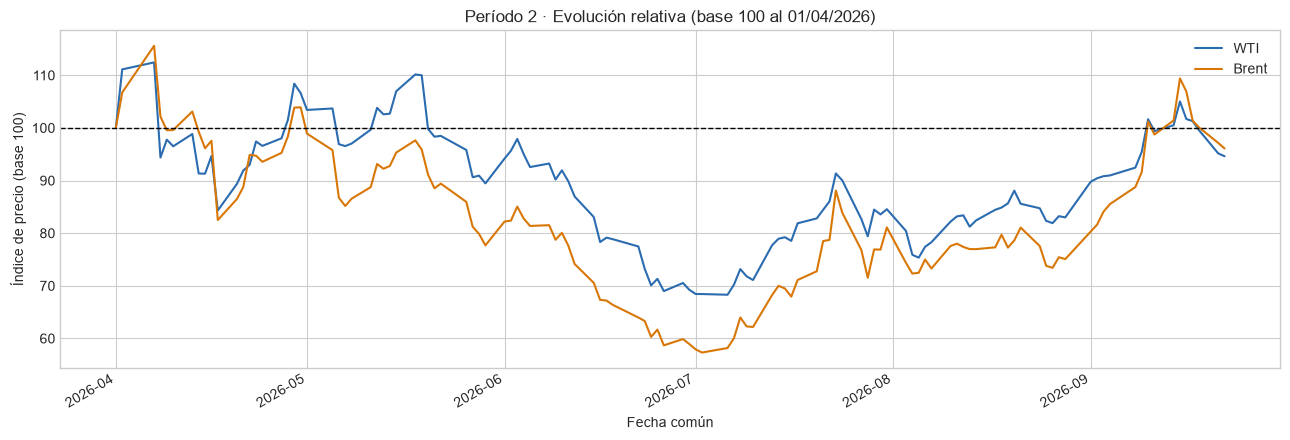

**Cómo leerlo.** Ambos precios parten de 100 en la primera fecha con cotización de los dos. Un valor de 110 representa una suba de 10%; uno de 90, una caída de 10%. Se utilizan fechas comunes y no se rellenan precios ausentes.

**Qué se observa.** Al 22/09/2026, WTI termina en 94.61 (-5.39% desde la base) y Brent en 96.09 (-3.91%). La diferencia en sus cambios acumulados es 1.48 puntos porcentuales. Este gráfico compara cambios proporcionales, no diferencias en dólares.

In [14]:
# Mismas fechas y misma fecha base para una comparación proporcional.
fecha_base_periodo_2 = precios_comunes_periodo_2.index[0]
base_100_periodo_2 = precios_comunes_periodo_2.div(
    precios_comunes_periodo_2.iloc[0]
).mul(100)
fig, ax = plt.subplots(figsize=(13, 4.5))
for crudo in crudos:
    ax.plot(base_100_periodo_2.index, base_100_periodo_2[crudo],
            color=colores[crudo], label=crudo)
ax.axhline(100, color="black", linestyle="--", linewidth=1)
ax.set(title=f"Período 2 · Evolución relativa (base 100 al {fecha_base_periodo_2:%d/%m/%Y})",
       xlabel="Fecha común", ylabel="Índice de precio (base 100)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

ultimo_indice = base_100_periodo_2.iloc[-1]
display(Markdown(
    "**Cómo leerlo.** Ambos precios parten de 100 en la primera fecha con cotización de los dos. "
    "Un valor de 110 representa una suba de 10%; uno de 90, una caída de 10%. "
    "Se utilizan fechas comunes y no se rellenan precios ausentes.\n\n"
    f"**Qué se observa.** Al {base_100_periodo_2.index[-1]:%d/%m/%Y}, "
    f"WTI termina en {ultimo_indice['WTI']:.2f} "
    f"({ultimo_indice['WTI'] - 100:+.2f}% desde la base) y "
    f"Brent en {ultimo_indice['Brent']:.2f} "
    f"({ultimo_indice['Brent'] - 100:+.2f}%). "
    f"La diferencia en sus cambios acumulados es "
    f"{abs(ultimo_indice['Brent'] - ultimo_indice['WTI']):.2f} puntos porcentuales. "
    "Este gráfico compara cambios proporcionales, no diferencias en dólares."
))

### Dispersión y valores extremos

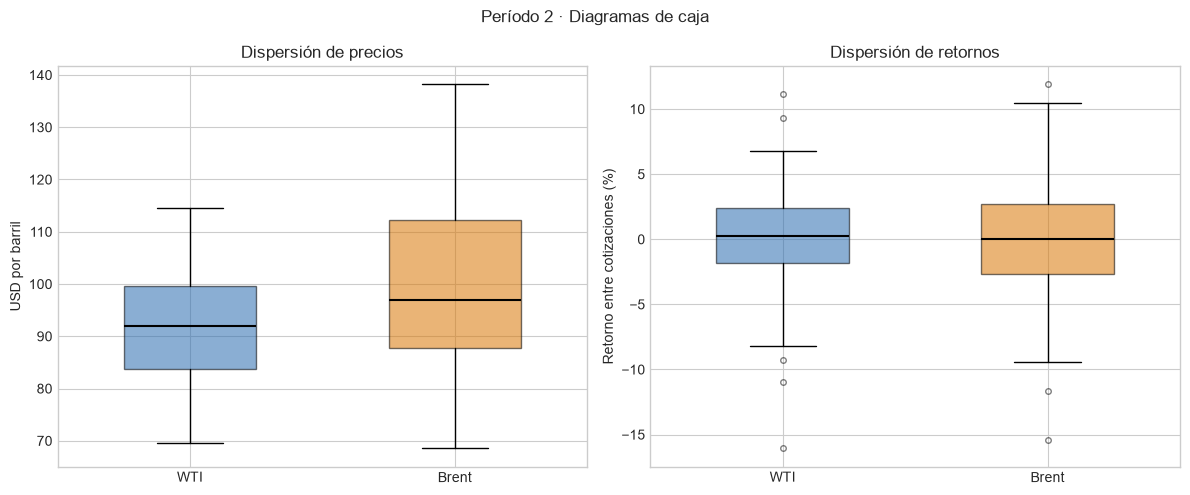

**Cómo leerlo.** La línea central es la mediana y la caja contiene el 50% central de los datos (Q1 a Q3). Los bigotes alcanzan los datos dentro de los límites de 1,5 veces el rango intercuartílico. Los puntos exteriores son valores para revisar, no errores demostrados. Una caja de precios más ancha describe dispersión en dólares; una caja de retornos más ancha describe variaciones porcentuales más dispersas.

**Qué se observa.**

- Precio: rango intercuartílico de WTI 15.97 y de Brent 24.47 USD por barril. Observaciones fuera de los bigotes: WTI 0; Brent 0.

- Retorno: rango intercuartílico de WTI 4.24 y de Brent 5.37 puntos porcentuales. Observaciones fuera de los bigotes: WTI 5; Brent 3.

Los puntos señalados se conservan en todos los cálculos y gráficos.

,medida,crudo,mediana,Q1,Q3,rango intercuartílico,límite inferior (1.5 RIQ),límite superior (1.5 RIQ),observaciones señaladas,asimetría muestral
0,Precio,WTI,92.025,83.685,99.655,15.970,59.730,123.610,0,-0.033
1,Precio,Brent,97.030,87.732,112.208,24.475,51.020,148.920,0,0.061
2,Retorno,WTI,0.236,-1.857,2.385,4.242,-8.219,8.747,5,-0.625
3,Retorno,Brent,-0.011,-2.690,2.676,5.366,-10.738,10.725,3,-0.143


La asimetría positiva sugiere una cola hacia valores altos; la negativa, hacia valores bajos. Es un resumen de la distribución, sensible a movimientos extremos.

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
filas_cajas = []
for ax, medida, series in [
    (axes[0], "Precio", series_precio_periodo_2),
    (axes[1], "Retorno", {crudo: retornos_periodo_2[crudo].dropna() for crudo in crudos}),
]:
    cajas = ax.boxplot(
        [series[crudo].to_numpy() for crudo in crudos],
        positions=[1, 2], widths=0.5, patch_artist=True, whis=1.5,
        medianprops={"color": "black", "linewidth": 1.5},
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
    )
    for caja, crudo in zip(cajas["boxes"], crudos):
        caja.set_facecolor(colores[crudo])
        caja.set_alpha(0.55)
    ax.set_xticks([1, 2], crudos)
    ax.set(title=f"Dispersión de {'precios' if medida == 'Precio' else 'retornos'}",
           ylabel="USD por barril" if medida == "Precio" else "Retorno entre cotizaciones (%)")
    for crudo in crudos:
        serie = series[crudo]
        q1, q3 = serie.quantile([0.25, 0.75])
        riq = q3 - q1
        inferior, superior = q1 - 1.5 * riq, q3 + 1.5 * riq
        extremos = serie.lt(inferior) | serie.gt(superior)
        filas_cajas.append({
            "medida": medida, "crudo": crudo,
            "mediana": serie.median(), "Q1": q1, "Q3": q3,
            "rango intercuartílico": riq,
            "límite inferior (1.5 RIQ)": inferior,
            "límite superior (1.5 RIQ)": superior,
            "observaciones señaladas": int(extremos.sum()),
            "asimetría muestral": serie.skew(),
        })
fig.suptitle("Período 2 · Diagramas de caja")
plt.tight_layout()
plt.show()

resumen_cajas_periodo_2 = pd.DataFrame(filas_cajas)
texto = [
    "**Cómo leerlo.** La línea central es la mediana y la caja contiene el 50% central "
    "de los datos (Q1 a Q3). Los bigotes alcanzan los datos dentro de los límites de "
    "1,5 veces el rango intercuartílico. Los puntos exteriores son valores para revisar, "
    "no errores demostrados. Una caja de precios más ancha describe dispersión en dólares; "
    "una caja de retornos más ancha describe variaciones porcentuales más dispersas.",
    "**Qué se observa.**",
]
for medida in ["Precio", "Retorno"]:
    filas = resumen_cajas_periodo_2.loc[resumen_cajas_periodo_2["medida"].eq(medida)]
    datos = filas.set_index("crudo")
    unidad = "USD por barril" if medida == "Precio" else "puntos porcentuales"
    texto.append(
        f"- {medida}: rango intercuartílico de WTI "
        f"{datos.loc['WTI', 'rango intercuartílico']:.2f} y de Brent "
        f"{datos.loc['Brent', 'rango intercuartílico']:.2f} {unidad}. "
        f"Observaciones fuera de los bigotes: WTI "
        f"{int(datos.loc['WTI', 'observaciones señaladas'])}; Brent "
        f"{int(datos.loc['Brent', 'observaciones señaladas'])}."
    )
texto.append("Los puntos señalados se conservan en todos los cálculos y gráficos.")
display(Markdown("\n\n".join(texto)))
display(resumen_cajas_periodo_2.round(3))
display(Markdown(
    "La asimetría positiva sugiere una cola hacia valores altos; la negativa, "
    "hacia valores bajos. Es un resumen de la distribución, sensible a movimientos extremos."
))

### Mayores subas y caídas

In [16]:
# Hasta cinco mayores subas y cinco mayores caídas por crudo.
partes_extremos = []
for crudo in crudos:
    datos = detalle_retornos_periodo_2.loc[
        detalle_retornos_periodo_2["crudo"].eq(crudo)
    ]
    for tipo, seleccion in [
        ("Mayor suba", datos.loc[datos["retorno_pct"].gt(0)].nlargest(5, "retorno_pct")),
        ("Mayor caída", datos.loc[datos["retorno_pct"].lt(0)].nsmallest(5, "retorno_pct")),
    ]:
        partes_extremos.append(seleccion.assign(tipo=tipo))
movimientos_extremos_periodo_2 = pd.concat(partes_extremos, ignore_index=True)[[
    "crudo", "tipo", "fecha_inicio", "fecha_fin", "dias_calendario",
    "precio_inicio", "precio_fin", "retorno_pct",
]]
display(movimientos_extremos_periodo_2.round({
    "precio_inicio": 2, "precio_fin": 2, "retorno_pct": 2,
}))
texto = [
    "La tabla conserva el precio inicial, el final y la duración de cada movimiento. "
    "Ordena magnitudes observadas; no utiliza el criterio de los bigotes para eliminar datos.",
]
for crudo in crudos:
    datos = detalle_retornos_periodo_2.loc[
        detalle_retornos_periodo_2["crudo"].eq(crudo)
    ]
    mayor = datos.loc[datos["retorno_pct"].abs().idxmax()]
    texto.append(
        f"- {crudo}: el mayor movimiento absoluto fue {mayor['retorno_pct']:+.2f}%, "
        f"entre {mayor['fecha_inicio']:%d/%m/%Y} y {mayor['fecha_fin']:%d/%m/%Y}, "
        f"en {int(mayor['dias_calendario'])} día(s) calendario."
    )
display(Markdown("\n\n".join(texto)))

,crudo,tipo,fecha_inicio,fecha_fin,dias_calendario,precio_inicio,precio_fin,retorno_pct
0,WTI,Mayor suba,2026-04-01,2026-04-02,1,101.90,113.23,11.12
1,WTI,Mayor suba,2026-07-10,2026-07-13,3,72.45,79.20,9.32
2,WTI,Mayor suba,2026-04-28,2026-04-29,1,103.45,110.47,6.79
3,WTI,Mayor suba,2026-09-09,2026-09-10,1,97.26,103.57,6.49
4,WTI,Mayor suba,2026-07-28,2026-07-29,1,80.91,86.08,6.39
5,WTI,Mayor caída,2026-04-07,2026-04-08,1,114.58,96.17,-16.07
6,WTI,Mayor caída,2026-04-16,2026-04-17,1,96.46,85.91,-10.94
7,WTI,Mayor caída,2026-05-19,2026-05-20,1,112.09,101.69,-9.28
8,WTI,Mayor caída,2026-07-24,2026-07-27,3,91.74,84.25,-8.16
9,WTI,Mayor caída,2026-04-13,2026-04-14,1,100.72,93.07,-7.60


La tabla conserva el precio inicial, el final y la duración de cada movimiento. Ordena magnitudes observadas; no utiliza el criterio de los bigotes para eliminar datos.

- WTI: el mayor movimiento absoluto fue -16.07%, entre 07/04/2026 y 08/04/2026, en 1 día(s) calendario.

- Brent: el mayor movimiento absoluto fue -15.43%, entre 16/04/2026 y 17/04/2026, en 1 día(s) calendario.

### Autocorrelación de los retornos

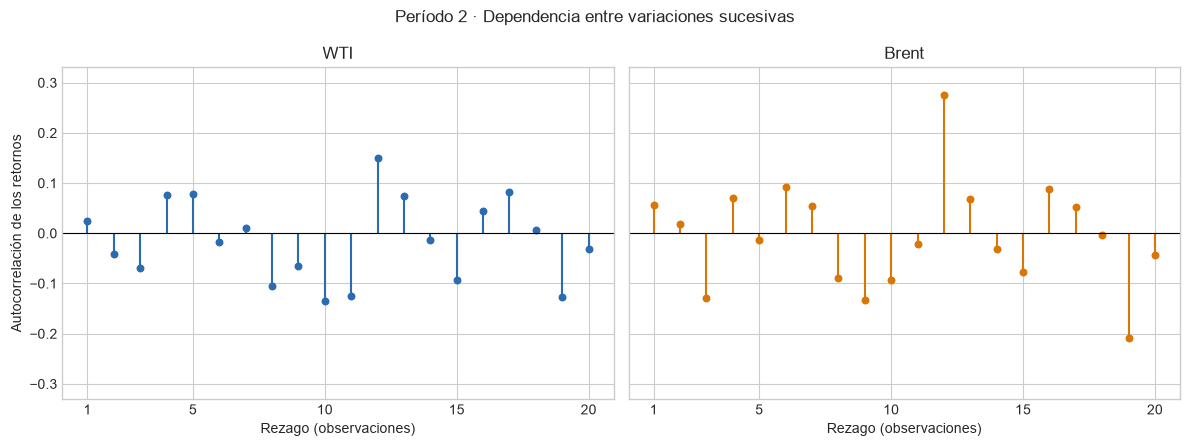

**Cómo leerlo.** El rezago 1 relaciona cada retorno con el anterior; el 5, con el de cinco observaciones atrás. Una correlación positiva indica asociación en el mismo sentido y una negativa, en sentido opuesto. Valores próximos a cero sugieren poca relación lineal para ese rezago.

**Qué se observa.**

- WTI: autocorrelación de rezago 1 = +0.025. Entre los rezagos explorados, el mayor valor absoluto está en el 12: +0.150, con 107 pares.

- Brent: autocorrelación de rezago 1 = +0.056. Entre los rezagos explorados, el mayor valor absoluto está en el 12: +0.276, con 107 pares.

Es una exploración descriptiva: el mayor valor entre varios rezagos puede surgir por azar y no se presenta como significancia estadística ni capacidad predictiva. Los rezagos representan observaciones consecutivas de cada crudo y pueden abarcar distintos días calendario. No se ajusta un modelo.

In [17]:
# Correlación de Pearson de la serie consigo misma desplazada k observaciones.
# El orden es el de las cotizaciones disponibles de cada crudo, no días calendario.
filas_autocorr = []
for crudo in crudos:
    serie = retornos_periodo_2[crudo].dropna().reset_index(drop=True)
    for rezago in range(1, min(20, len(serie) - 2) + 1):
        filas_autocorr.append({
            "crudo": crudo, "rezago": rezago,
            "autocorrelación": serie.autocorr(lag=rezago),
            "pares utilizados": len(serie) - rezago,
        })
autocorrelacion_periodo_2 = pd.DataFrame(filas_autocorr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
magnitud = autocorrelacion_periodo_2["autocorrelación"].abs().max()
limite = min(1.0, max(0.3, 1.2 * magnitud)) if pd.notna(magnitud) else 1.0
for ax, crudo in zip(axes, crudos):
    tabla = autocorrelacion_periodo_2.loc[autocorrelacion_periodo_2["crudo"].eq(crudo)]
    ax.vlines(tabla["rezago"], 0, tabla["autocorrelación"], color=colores[crudo])
    ax.scatter(tabla["rezago"], tabla["autocorrelación"], color=colores[crudo], s=22)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=crudo, xlabel="Rezago (observaciones)", ylim=(-limite, limite))
    ax.set_xticks([1, 5, 10, 15, 20])
axes[0].set_ylabel("Autocorrelación de los retornos")
fig.suptitle("Período 2 · Dependencia entre variaciones sucesivas")
plt.tight_layout()
plt.show()

texto = [
    "**Cómo leerlo.** El rezago 1 relaciona cada retorno con el anterior; "
    "el 5, con el de cinco observaciones atrás. Una correlación positiva indica "
    "asociación en el mismo sentido y una negativa, en sentido opuesto. "
    "Valores próximos a cero sugieren poca relación lineal para ese rezago.",
    "**Qué se observa.**",
]
for crudo in crudos:
    tabla = autocorrelacion_periodo_2.loc[
        autocorrelacion_periodo_2["crudo"].eq(crudo)
    ].dropna(subset=["autocorrelación"])
    if tabla.empty:
        texto.append(f"- {crudo}: no se puede estimar la autocorrelación con estos datos.")
        continue
    pico = tabla.loc[tabla["autocorrelación"].abs().idxmax()]
    primer = tabla.loc[tabla["rezago"].eq(1), "autocorrelación"]
    texto.append(
        f"- {crudo}: autocorrelación de rezago 1 = "
        f"{primer.iloc[0] if len(primer) else float('nan'):+.3f}. "
        f"Entre los rezagos explorados, el mayor valor absoluto está en el "
        f"{int(pico['rezago'])}: {pico['autocorrelación']:+.3f}, "
        f"con {int(pico['pares utilizados'])} pares."
    )
texto.append(
    "Es una exploración descriptiva: el mayor valor entre varios rezagos puede surgir "
    "por azar y no se presenta como significancia estadística ni capacidad predictiva. "
    "Los rezagos representan observaciones consecutivas de cada crudo y pueden abarcar "
    "distintos días calendario. No se ajusta un modelo."
)
display(Markdown("\n\n".join(texto)))

In [18]:
variaciones_periodo_2 = pd.Series({
    crudo: (serie.iloc[-1] / serie.iloc[0] - 1) * 100
    for crudo, serie in series_precio_periodo_2.items()
})
crudo_mas_volatil_periodo_2 = volatilidad_diaria_periodo_2.idxmax()
display(Markdown(
    f"**Lectura conjunta del período 2.**\n\n"
    f"- WTI cambió {variaciones_periodo_2['WTI']:+.2f}% y Brent "
    f"{variaciones_periodo_2['Brent']:+.2f}% entre sus respectivas primeras y últimas cotizaciones.\n"
    f"- El desvío de los retornos fue {volatilidad_diaria_periodo_2['WTI']:.2f} "
    f"puntos porcentuales para WTI y {volatilidad_diaria_periodo_2['Brent']:.2f} para Brent. "
    f"{crudo_mas_volatil_periodo_2} presentó el valor mayor.\n"
    f"- La correlación de retornos fue {corr_retornos_periodo_2:.3f}, "
    f"calculada con {len(retornos_comparables_periodo_2)} intervalos de inicio y fin idénticos.\n"
    f"- El spread Brent−WTI promedió USD {spread_periodo_2.mean():.2f}, "
    f"sobre {len(spread_periodo_2)} fechas comunes.\n\n"
    "Las distribuciones, los extremos y la autocorrelación complementan la evolución temporal. "
    "Estos resultados describen exclusivamente este período y deben leerse junto con "
    "su cobertura: hay intervalos de distinta duración y pueden existir meses parciales. "
    "Los valores extremos se conservan y las asociaciones no establecen causas."
))

**Lectura conjunta del período 2.**

- WTI cambió -5.39% y Brent -3.91% entre sus respectivas primeras y últimas cotizaciones.
- El desvío de los retornos fue 3.90 puntos porcentuales para WTI y 4.42 para Brent. Brent presentó el valor mayor.
- La correlación de retornos fue 0.854, calculada con 110 intervalos de inicio y fin idénticos.
- El spread Brent−WTI promedió USD 7.98, sobre 117 fechas comunes.

Las distribuciones, los extremos y la autocorrelación complementan la evolución temporal. Estos resultados describen exclusivamente este período y deben leerse junto con su cobertura: hay intervalos de distinta duración y pueden existir meses parciales. Los valores extremos se conservan y las asociaciones no establecen causas.